# 7 — Combining datasets

**Theme:** joining data along time, and joining it across size.

Two different operations are easy to confuse:

- **`combine_measurements`** joins runs of the *same* instrument along the time
  axis — three days of monitoring into one record.
- **`combine_size_ranges`** joins *two different* instruments covering
  neighbouring size ranges into one wider distribution, over the same period.

Both differ from `load_data_from_folder`, which is about reading many files of
one instrument at load time — see [1 — Loading data](01-loading-data.ipynb).

In [1]:
import aerosoltools as at

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Joining runs along time

A Ranger with interchangeable heads returns one object per measured component,
so pick the component you want from each file first.

In [2]:
def chlorine(path):
    loaded = at.load_ranger_file(path)
    objects = loaded if isinstance(loaded, list) else [loaded]
    return next(o for o in objects if o.dtype == "Cl₂")


runs = [
    chlorine("../../tests/data/Ranger_2605-1000088-A_20260612-0603.csv"),
    chlorine("../../tests/data/Ranger_2605-1000088-A_20260617-0712.csv"),
    chlorine("../../tests/data/Ranger_2605-1000088-A_20260701-0832.csv"),
]

for run in runs:
    print(f"{len(run.data):5d} samples   {run.time[0]}  ->  {run.time[-1]}")

 1578 samples   2026-05-19 09:44:00  ->  2026-06-11 12:10:00
 1020 samples   2026-06-16 11:24:00  ->  2026-06-17 04:23:00
 2033 samples   2026-06-16 11:24:00  ->  2026-07-01 04:17:00


In [3]:
campaign = at.combine_measurements(runs)

print(f"combined: {len(campaign.data)} samples")
print(f"          {campaign.time[0]}  ->  {campaign.time[-1]}")
print(f"          {campaign.dtype} in {campaign.unit}")

combined: 3611 samples
          2026-05-19 09:44:00  ->  2026-07-01 04:17:00
          Cl₂ in ppm


The result is one object of the same class, sorted by time and de-duplicated.
Gaps between runs are preserved — nothing is interpolated across them, so a
weekend with no measurement stays a hole rather than becoming a straight line.

Note the combined length is smaller than the sum of the inputs: overlapping
timestamps are collapsed rather than duplicated.

By default all inputs must share a serial number, which is what stops two
different instruments being silently concatenated. Pass
`require_same_serial=False` when the metadata is missing and you know the
inputs belong together.

Text(0.5, 1.0, 'Three runs combined into one record')

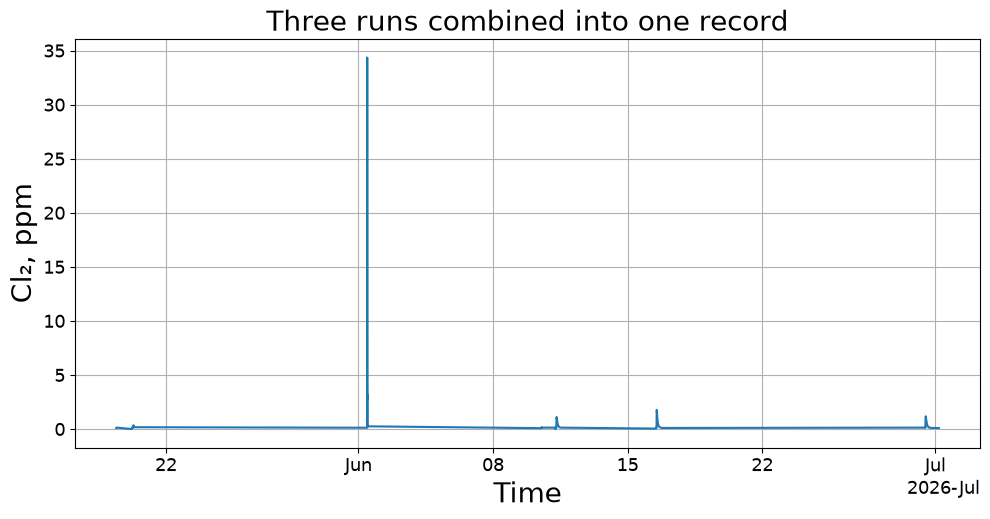

In [4]:
fig, ax = campaign.plot_total_conc()
ax.set_title("Three runs combined into one record")

## Joining across size

No single instrument covers the whole size range. A NanoScan measures roughly
10–400 nm; an OPS roughly 300 nm–10 µm. `combine_size_ranges` stitches them
into one distribution.

In [5]:
ns = at.load_ns_file("../../tests/data/Combine_example_NS.csv")
ops = at.load_data_from_folder(
    "../../tests/data", at.load_ops_file, search_word="Combine_example"
)

print(f"NanoScan: {ns.bin_mids.min():.0f} - {ns.bin_mids.max():.0f} nm")
print(f"OPS     : {ops.bin_mids.min():.0f} - {ops.bin_mids.max():.0f} nm")

Loading files:   0%|          | 0/5 [00:00<?, ?file/s]

Loading files: 100%|██████████| 5/5 [00:00<00:00, 130.91file/s]


File load summary:

+----------------------------------+---------+------------------------------------------------------------------------------------+
|               File               | Status  |                                       Reason                                       |
+----------------------------------+---------+------------------------------------------------------------------------------------+
| Combine_example_OPS - file 1.csv | Loaded  |                                         -                                          |
| Combine_example_OPS - file 2.csv | Loaded  |                                         -                                          |
| Combine_example_OPS - file 3.csv | Loaded  |                                         -                                          |
| Combine_example_OPS - file 4.csv | Loaded  |                                         -                                          |
|      Combine_example_NS.csv      | Skipped | IndexErr

The two instruments log on different clocks, so they must be aligned in time
first. `match="nearest"` pairs each NanoScan sample with the closest OPS sample
within `tolerance`; `match="rebin"` puts both onto a common grid instead.

In [6]:
combined = at.combine_size_ranges(ns, ops, match="nearest", tolerance="30s")

print(f"combined: {combined.bin_mids.min():.0f} - {combined.bin_mids.max():.0f} nm")
print(f"          {len(combined.bin_mids)} bins, {len(combined.data)} samples")

combined: 12 - 9016 nm
          28 bins, 9582 samples


Where the ranges overlap, one instrument has to win. The crossover diameter
decides: bins below it come from the lower instrument, bins above from the
upper. Left as `None` it is chosen automatically; set it explicitly when you
have a reason to trust one instrument over the other in the overlap.

The crossover has to lie *inside* the shared overlap — asking for one outside
it raises rather than silently discarding a range.

In [7]:
print(f"shared overlap: {ops.bin_mids.min():.0f} - {ns.bin_mids.max():.0f} nm")

low = at.combine_size_ranges(ns, ops, crossover=320, match="nearest", tolerance="30s")
high = at.combine_size_ranges(ns, ops, crossover=400, match="nearest", tolerance="30s")

print(f"crossover 320 nm -> {len(low.bin_mids)} bins")
print(f"crossover 400 nm -> {len(high.bin_mids)} bins")

shared overlap: 337 - 365 nm
crossover 320 nm -> 28 bins
crossover 400 nm -> 27 bins


In [8]:
try:
    at.combine_size_ranges(ns, ops, crossover=700, match="nearest", tolerance="30s")
except ValueError as err:
    print("ValueError:", err)

ValueError: crossover 700.0 nm is outside the instruments' shared overlap (300.0-420.0 nm).


The result is an ordinary size-resolved dataset, so everything from the earlier
notebooks applies to it.

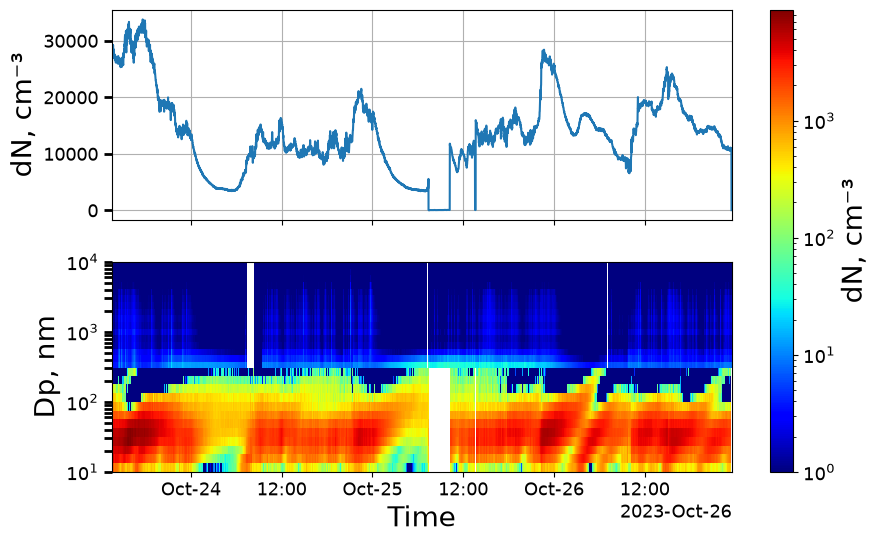

In [9]:
fig, axs = combined.plot_timeseries(y_3d=(1, 0))

Text(0.5, 1.0, 'Stitched distribution, 10 nm to 10 um')

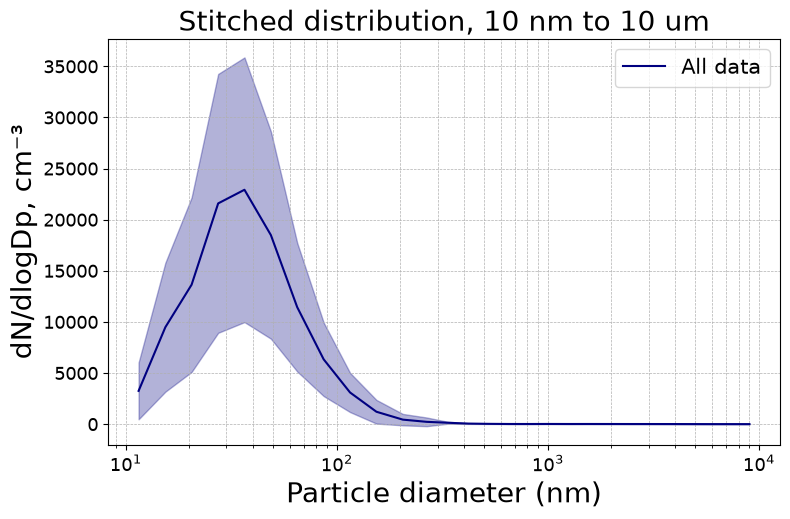

In [10]:
fig, ax = combined.plot_psd()
ax.set_title("Stitched distribution, 10 nm to 10 um")

---

**Next:** [8 — PSD fitting](08-psd-fitting.ipynb).